notebook to verify, preprocess, and analyze conversion data!

*data cleaning (timezone ground truth, math_only timezone extraction, bra_size extraction) is handled in `clean_results.ipynb`*

**NOTE**: be sure to run ```clean_results.ipynb``` before this to update ```clean_results.tsv``` with all the data in ```/full_results/```

**if the data isn't fully complete there may be inaccuracies in this file**

### data validation ###

1. combine everything into a dataframe and validate/do sanity checks to ensure everything looks good

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import glob
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


pd.set_option('display.float_format', '{:.3f}'.format)

In [37]:
# All models (excluding broken qwen3-235b)
NON_REASONING_MODELS = ['gpt-4o', 'claude-haiku-4-5', 'qwen-coder', 'llama-4']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

# Conditions mapped to subdirectories
CONDITIONS = {
    'regular':   'results',
    'no_guide':  'results_no_guide',
    'math_only': 'results_math_only',
}

# Nice display names & colors
MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'claude-haiku-4-5': 'Claude-Haiku-4.5',
    'qwen-coder': 'Qwen3-Coder-480B',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    'qwen3-235b-thinking': 'Qwen3-235B-Think ★',
    'qwen3-next-thinking': 'Qwen3-Next-Think ★',
}

# MODEL_COLORS = {
#     'gpt-4o': '#1f77b4',
#     'qwen-coder': '#ff7f0e',
#     'llama-4': '#2ca02c',
#     'gpt-5.2': '#d62728',
#     'deepseek-v3.1': '#9467bd',
#     'qwen3-235b-thinking': '#8c564b',
#     'qwen3-next-thinking': '#e377c2',
# }

print(f"Non-reasoning models: {NON_REASONING_MODELS}")
print(f"Reasoning models:     {REASONING_MODELS}")

Non-reasoning models: ['gpt-4o', 'claude-haiku-4-5', 'qwen-coder', 'llama-4']
Reasoning models:     ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']


In [38]:
BASE_DIR = Path('full_results')

SUBDIR_TO_CONDITION = {v: k for k, v in CONDITIONS.items()}

def parse_model(f):
    return f.parts[2]

def parse_cond(f):
    return SUBDIR_TO_CONDITION.get(f.parts[1], f.parts[1])

def parse_domain(f):
    return (f.parts[3]
            .replace('_converted', '')
            .replace('_math_only', '')
            .replace('_no_guide', '')
            .replace('.tsv', ''))

# # load every TSV and tag with model/condition/domain
# files = sorted(BASE_DIR.glob('*/*/*_converted.tsv'))
# frames = []
# for f in files:
#     try:
#         df = pd.read_csv(f, sep='\t')
#         df = df.assign(model=parse_model(f), condition=parse_cond(f), domain=parse_domain(f))
#         frames.append(df)
#     except Exception as e:
#         print(f"⚠ Could not read {f}: {e}")

# df_all = pd.concat(frames, ignore_index=True)
# print(f"loaded {len(df_all):,} rows from {len(files)} files")
# print(f"columns: {df_all.columns.tolist()}")

In [39]:
# rename conditions 
# df_all['condition'] = df_all['condition'].replace({'math_only': 'math_only', 'no_guide': 'in_domain_no_guide', 'regular': 'in_domain_with_guide'})

In [40]:
# # load in the pile number frequencies
# import json, gzip

# with gzip.open("/Users/kzhou/pile_number_frequency/int_counts.json.gz", "rt") as f:
#     int_counts = json.load(f)
# with gzip.open("/Users/kzhou/pile_number_frequency/float_counts.json.gz", "rt") as f:
#     float_counts = json.load(f)

# print(f"Unique integers: {len(int_counts):,}")
# print(f"Unique floats:   {len(float_counts):,}")
# print(f"Total int occurrences:   {sum(c for _, c in int_counts):,}")
# print(f"Total float occurrences: {sum(c for _, c in float_counts):,}")

In [41]:
# df_intcount = pd.DataFrame(int_counts, columns=['number', 'frequency'])
# df_floatcount = pd.DataFrame(float_counts, columns=['number', 'frequency'])

# # Normalise: convert to float first (to collapse "1" and "1.0"),
# # then back to string, stripping ".0" from integers so keys match df_all['number'] (object)
# df_intcount['number'] = df_intcount['number'].astype(float).astype(str).str.replace(r'\.0$', '', regex=True)
# df_floatcount['number'] = df_floatcount['number'].astype(float).astype(str).str.replace(r'\.0$', '', regex=True)

# df_intcount.head()

In [42]:
# # merge int and float counts into one dataframe
# # sum frequencies where the same number appears in both (e.g. "1" in ints and "1.0" in floats)
# df_counts = (
#     pd.concat([df_intcount, df_floatcount], ignore_index=True)
#     .groupby('number', as_index=False)['frequency']
#     .sum()
# )
# # Normalise df_all['number'] the same way: strip trailing ".0" from integer-like values
# df_all['number'] = df_all['number'].astype(str).str.replace(r'\.0$', '', regex=True)

# # merge counts into larger dataframe, number as key, keep all rows in df_all
# df_all = pd.merge(df_all, df_counts, on='number', how='left')
# df_all.to_csv("temp.tsv", sep="\t")


In [43]:
df_all = pd.read_csv("temp.tsv", sep="\t")



/var/folders/r3/0y317n4x2t76wwwg3b788cmc0000gn/T/ipykernel_27209/2804379572.py:1: DtypeWarning: Columns (2,8,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("temp.tsv", sep="\t")


In [44]:
# Split frequency into quantile-based bins (log-space for Zipf)

df_all = df_all.dropna(subset=['frequency'])
df_all['frequency'] = df_all['frequency'].clip(lower=1)
df_all['frequency_level'] = pd.qcut(
    np.log10(df_all['frequency']),
    q=4,
    labels=['rare', 'uncommon', 'common', 'very_common'],
)

print(df_all['frequency_level'].value_counts())
print(f"\nLog10 quantile boundaries:")
log_q = np.log10(df_all['frequency']).quantile([0, 0.25, 0.5, 0.75, 1.0])
print(pd.DataFrame({'log10_freq': log_q, 'freq': 10**log_q}).round(1))



frequency_level
uncommon       61427
rare           61295
very_common    60450
common         59358
Name: count, dtype: int64

Log10 quantile boundaries:
       log10_freq          freq
0.000       0.300         2.000
0.250       2.700       542.000
0.500       6.200   1757767.000
0.750       7.200  14556990.000
1.000       8.900 858798582.000


In [45]:
df_all['is_reasoning'] = df_all['model'].isin(REASONING_MODELS)
df_all['display_name'] = df_all['model'].map(MODEL_DISPLAY)

In [46]:
# group all domains containing "clothing_size" under "clothing_size"
df_all.loc[df_all['domain'].str.contains('clothing_size', na=False), 'domain'] = 'clothing_size'

note to self/reader: 

loss is computed in different ways depending on domain.
numerical: loss is the relative percentage error between real and model answer, unless those are within a 1% error, in which case loss = 0.0.
timezone: loss is # of minutes difference between real and model answer. if they are 1 minute off, loss is 0.0.
clothing size: binary loss. 1 if incorrect, 0 if correct.

**calculate accuracy and other statistics**

In [47]:
# calculate accuracy/correctness based on loss
df_all['is_correct'] = df_all['loss'] == 0.0

In [48]:
# make stats dataframe
df_stats = (
    df_all
    .groupby(['model', 'condition', 'domain'])['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
    .reset_index()
)

df_stats['accuracy_%'] = df_stats['accuracy'].mul(100)
df_stats.head()

,model,condition,domain,accuracy,n,accuracy_%
0,claude-haiku-4-5,in_domain_no_guide,bits_bytes,0.593,600,59.333
1,claude-haiku-4-5,in_domain_no_guide,clothing_size,0.000,180,0.000
2,claude-haiku-4-5,in_domain_with_guide,bits_bytes,0.843,600,84.333
3,claude-haiku-4-5,in_domain_with_guide,clothing_size,0.000,180,0.000
4,claude-haiku-4-5,math_only,bits_bytes,0.677,600,67.667


In [49]:
# test how number of decimal places in model_answer affects accuracy
# model_answer is numeric, so convert to string first and strip trailing zeros
# e.g. 46.0 → "46" (0 decimals), 0.85 → "0.85" (2 decimals), 0.2778 → "0.2778" (4 decimals)
_ma_str = df_all['model_answer'].astype(str)
_ma_clean = _ma_str.str.replace(r'\.0+$', '', regex=True)           # 46.0 → 46
_ma_clean = _ma_clean.str.replace(r'(\.\d*?)0+$', r'\1', regex=True)  # strip trailing 0s after decimal
_has_dot = _ma_clean.str.contains(r'\.', na=False)
df_all['num_decimals'] = (
    _ma_clean.str.split('.').str[-1].str.len()
    .where(_has_dot, 0)
    .astype(int)
)
df_all.groupby(['model', 'condition', 'num_decimals']).agg({'is_correct': 'mean'}).reset_index()


,model,condition,num_decimals,is_correct
0,claude-haiku-4-5,in_domain_no_guide,0,0.481
1,claude-haiku-4-5,in_domain_no_guide,1,1.000
2,claude-haiku-4-5,in_domain_no_guide,2,1.000
3,claude-haiku-4-5,in_domain_no_guide,3,0.796
4,claude-haiku-4-5,in_domain_no_guide,4,0.148
...,...,...,...,...
302,qwen3-235b-thinking,math_only,13,1.000
303,qwen3-235b-thinking,math_only,14,1.000
304,qwen3-235b-thinking,math_only,15,1.000
305,qwen3-235b-thinking,math_only,16,1.000


In [50]:
_ip_str = df_all['number'].astype(str)
_ip_clean = _ip_str.str.replace(r'\.0+$', '', regex=True)           # 46.0 → 46
_ip_clean = _ip_clean.str.replace(r'(\.\d*?)0+$', r'\1', regex=True)  # strip trailing 0s after decimal
_has_dot = _ip_clean.str.contains(r'\.', na=False)
df_all['num_input_decimals'] = (
    _ip_clean.str.split('.').str[-1].str.len()
    .where(_has_dot, 0)
    .astype(int)
)
df_all.groupby(['model', 'condition', 'num_input_decimals']).agg({'is_correct': 'mean'}).reset_index()

,model,condition,num_input_decimals,is_correct
0,claude-haiku-4-5,in_domain_no_guide,0,0.507
1,claude-haiku-4-5,in_domain_no_guide,1,0.000
2,claude-haiku-4-5,in_domain_with_guide,0,0.721
3,claude-haiku-4-5,in_domain_with_guide,1,0.000
4,claude-haiku-4-5,math_only,0,0.677
...,...,...,...,...
105,qwen3-235b-thinking,math_only,1,0.978
106,qwen3-235b-thinking,math_only,2,0.981
107,qwen3-235b-thinking,math_only,3,0.979
108,qwen3-235b-thinking,math_only,4,0.986


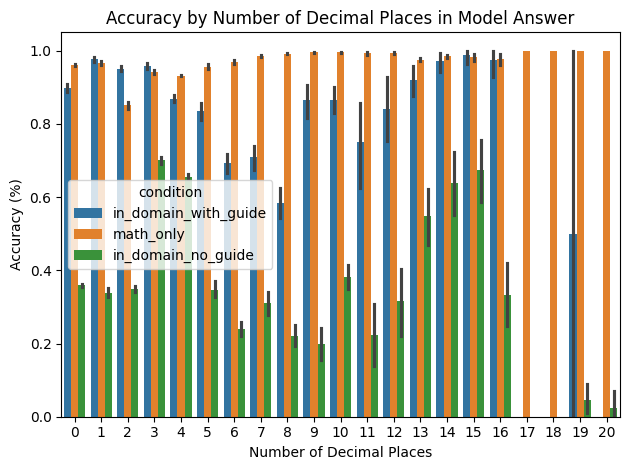

In [51]:
# visualize accuracy 

sns.barplot(data=df_all, x='num_decimals', y='is_correct',hue='condition')
plt.title('Accuracy by Number of Decimal Places in Model Answer')
plt.xlabel('Number of Decimal Places')
plt.ylabel('Accuracy (%)')
# plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

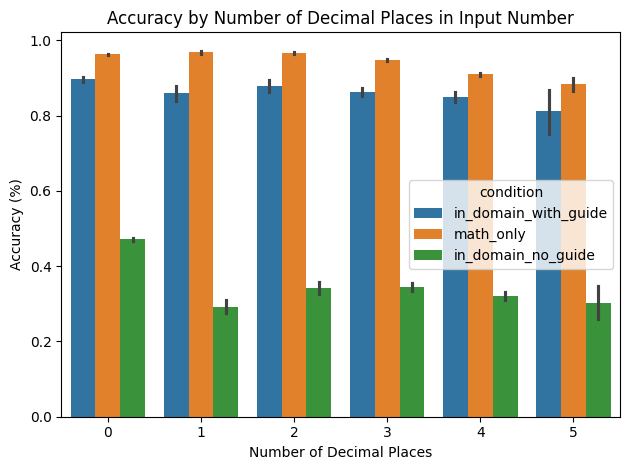

In [52]:
sns.barplot(data=df_all, x='num_input_decimals', y='is_correct', hue='condition')
plt.title('Accuracy by Number of Decimal Places in Input Number')
plt.xlabel('Number of Decimal Places')
plt.ylabel('Accuracy (%)')
# plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [53]:
no_guide = df_all[df_all['condition'] == 'in_domain_no_guide']
no_guide.groupby(['model','condition']).agg({'loss': 'mean'}).round(3).reset_index()

,model,condition,loss
0,claude-haiku-4-5,in_domain_no_guide,1.477
1,deepseek-v3.1,in_domain_no_guide,17280429.230
2,gpt-4o,in_domain_no_guide,934.396
3,gpt-5.2,in_domain_no_guide,389743.405
4,gpt-oss-120b,in_domain_no_guide,16455.891
5,llama-4,in_domain_no_guide,849256900714.535
6,qwen-coder,in_domain_no_guide,26541135.783
7,qwen3-235b-thinking,in_domain_no_guide,0.912


In [54]:
no_guide.groupby("frequency_level").mean(numeric_only=True).reset_index()

,frequency_level,Unnamed: 0,number,answer,loss,reasoning_tokens,call_seconds,frequency,is_reasoning,is_correct,num_decimals,num_input_decimals
0,rare,237587.443,836.098,250122.728,548652.499,301.421,76.662,119.215,0.744,0.341,3.470,2.800
1,uncommon,251772.937,6375.605,9206305.867,11125057.654,138.990,50.095,743851.908,0.394,0.408,2.145,1.117
2,common,258413.823,3177.350,4594184.951,27687.752,65.120,36.385,6065372.271,0.224,0.474,1.441,0.006
3,very_common,257600.426,75.583,108710.007,137256601745.367,59.658,25.576,110235321.854,0.227,0.475,1.755,0.000


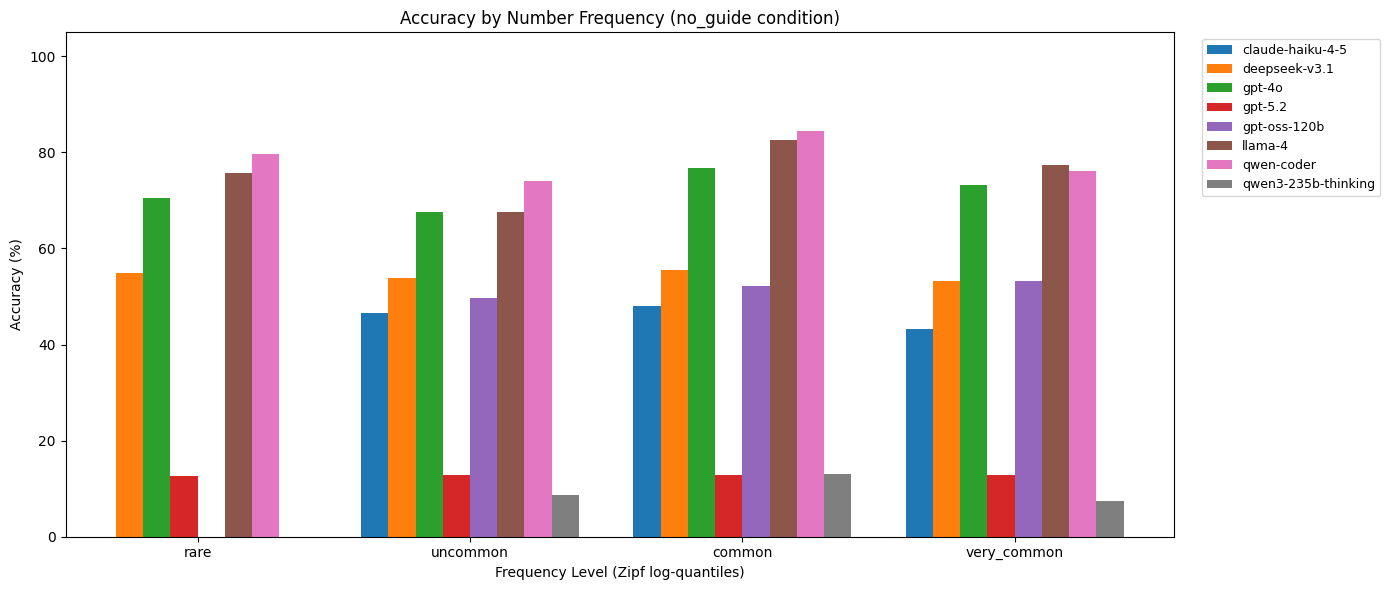

In [56]:
acc = (
    no_guide[['model', 'frequency_level', 'is_correct']]
    .groupby(['model', 'frequency_level'])
    .mean()
    .reset_index()
    .rename(columns={'is_correct': 'accuracy'})
)
acc['accuracy_%'] = acc['accuracy'] * 100

freq_order = ['rare', 'uncommon', 'common', 'very_common']
acc['frequency_level'] = pd.Categorical(acc['frequency_level'], categories=freq_order, ordered=True)
acc = acc.sort_values(['model', 'frequency_level'])

fig, ax = plt.subplots(figsize=(14, 6))
models = sorted(acc['model'].unique())
x = np.arange(len(models))
width = 0.8 / len(freq_order)

for i, level in enumerate(freq_order):
    sub = acc[acc['frequency_level'] == level].set_index('model').loc[models]
    ax.bar(x + i * width, sub['accuracy_%'].values, width, label=level)

ax.set_xticks(x + width * (len(freq_order) - 1) / 2)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Number Frequency (no_guide condition)')
ax.legend(title='Frequency Level')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [34]:
no_guide[['model', 'frequency_level', 'is_correct']].groupby(['model', 'frequency_level']).mean()

is_correct
model               frequency_level            
claude-haiku-4-5    rare                    NaN
                    uncommon              0.466
                    common                0.480
                    very_common           0.432
deepseek-v3.1       rare                  0.548
                    uncommon              0.538
                    common                0.555
                    very_common           0.533
gpt-4o              rare                  0.706
                    uncommon              0.677
                    common                0.768
                    very_common           0.732
gpt-5.2             rare                  0.126
                    uncommon              0.129
                    common                0.129
                    very_common           0.128
gpt-oss-120b        rare                    NaN
                    uncommon              0.496
                    common                0.522
                    very_common           0.533
llama-4             rare                  0.758
                    uncommon              0.677
                    common                0.826
                    very_common           0.774
qwen-coder          rare                  0.797
                    uncommon              0.740
                    common                0.844
                    very_common           0.761
qwen3-235b-thinking rare                    NaN
                    uncommon              0.086
                    common                0.132
                    very_common           0.074